In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\functions\query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:
llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = False # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: False, Database: bird


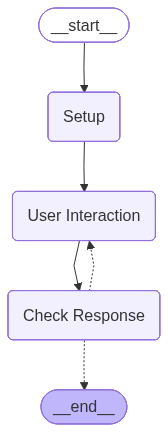

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]
    try: 
        # Se o experimento já foi avaliado, pula para o próximo
    
        if exp_id in processed_ids or exp_id == "14": # --- IGNORE ---
            print(f"Pulando experimento {exp_id} já processado.")
            continue

        print(f"Processando experimento {exp_id}...")

        config =  {"recursion_limit": 50}
        # Invoca a avaliação com as configurações estendidas
        eval_result = eval_graph.invoke({
            "experiment": experiment,
            "max_retries": 2,
            "debug_mode": True,
            "model_version": model_version,
            "experiment_type": experiment_type,
           
        }, config=config)

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get("experiment_config", {
                "max_retries": 2,
                "model_version": model_version,
                "timestamp": datetime.now().isoformat(),
                "experiment_type": experiment_type
            }),
            "experiment_eval": eval_result["experiment_eval"]
        })

        # Atualiza o arquivo salvando o resultado atual
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)
    except Exception as e:
        print(f"Erro ao processar experimento {exp_id}: {e}")


Pulando experimento 1 já processado.
Pulando experimento 2 já processado.
Pulando experimento 3 já processado.
Pulando experimento 4 já processado.
Pulando experimento 5 já processado.
Pulando experimento 7 já processado.
Pulando experimento 8 já processado.
Pulando experimento 9 já processado.
Pulando experimento 10 já processado.
Pulando experimento 11 já processado.
Pulando experimento 12 já processado.
Pulando experimento 13 já processado.
Pulando experimento 14 já processado.
Pulando experimento 15 já processado.
Pulando experimento 16 já processado.
Pulando experimento 17 já processado.
Pulando experimento 18 já processado.
Pulando experimento 19 já processado.
Pulando experimento 20 já processado.
Pulando experimento 21 já processado.
Pulando experimento 22 já processado.
Pulando experimento 23 já processado.
Pulando experimento 25 já processado.
Pulando experimento 26 já processado.
Processando experimento 28...
[NODE] Setup Node entered.
---------------------------------------

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Provide the details of constructors who have participated in races along with their standings.",
    "schema_linking": ["formula_1_constructors", "formula_1_constructorstandings"],
    "answer": "The query retrieved details of constructors such as their name, nationality, points, position, and wins in the standings. For example, McLaren (British) scored 14 points, ranked 1st, and achieved 1 win; BMW Sauber (German) scored 8 points, ranked 3rd with no wins; Williams (British) scored 9 points, ranked 2nd with no wins; Renault (French) scored 5 points, ranked 4th with no wins; Toro Rosso (Italian) scored 2 points, ranked 5th with no wins, and many more similar records.",
    "sql": "SELECT c.name AS constructor_name, c.nationality, cs.points, cs.position, cs.wins FROM formula_1_constructors c JOIN formula_1_constructorstandings cs ON c.constructorid = cs.constructorid"
}.

----------------------------------------
[NODE] Check Response No

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


True cols: Index(['NAME', 'NATIONALITY', 'POINTS', 'POSITION'], dtype='object')
Adj. True cols: Index(['NAME', 'NATIONALITY', 'POINTS', 'POSITION'], dtype='object')
Predicted cols: Index(['CONSTRUCTOR_NAME', 'NATIONALITY', 'POINTS', 'POSITION', 'WINS'], dtype='object')
Adj. Predicted cols: Index(['CONSTRUCTOR_NAME', 'NATIONALITY', 'POINTS', 'POSITION'], dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Provide details of constructors who have participated in races along with their standings.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Can you tell me the details of constructors who have participated in races along with their standings?', 'agent_reply': 'The query retrieved details of constructors such as their name, nationality, points, position, and wins in the standings. For example, McLaren (British) scored 14 points, ranked 1st, and achieved 1 win; BMW Sauber (German) scored 8 points, ranked 

...

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "Show the lap times for each driver.",
    "schema_linking": ["formula_1_laptimes"],
    "answer": "Unable to retrieve the lap times due to a database connection issue. Error: DPY-1001: not connected to database.",
    "sql": "SELECT lt.driverid, lt.lap, lt.time FROM formula_1_laptimes lt"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Show the lap times for each driver.",
    "schema_linking": ["formula_1_laptimes"],
    "answer": "Unable to retrieve the lap times due to a database connection issue. Error: DPY-1001: not connected to database.",
    "sql": "SELECT lt.driverid, lt.lap, lt.time FROM formula_1_laptimes lt"
}.

[INFO] Avaliando o resultado: {'input': 'Show the lap times for each driver.', 'schema_linking': ['formula_1_laptimes'], 'answer': 'Unable to retrieve the lap times due to a database connection issue. Error: DPY-1001: not connected

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(


[INFO] O resultado da execução foi: {
    "input": "List the names of all German drivers.",
    "schema_linking": ["formula_1_drivers"],
    "answer": "The query execution failed due to a database connection issue. Error: DPY-1001: not connected to database.",
    "sql": "SELECT forename, surname FROM formula_1_drivers WHERE LOWER(nationality) = LOWER('German')"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "List the names of all German drivers.",
    "schema_linking": ["formula_1_drivers"],
    "answer": "The query execution failed due to a database connection issue. Error: DPY-1001: not connected to database.",
    "sql": "SELECT forename, surname FROM formula_1_drivers WHERE LOWER(nationality) = LOWER('German')"
}.

[INFO] Avaliando o resultado: {'input': 'List the names of all German drivers.', 'schema_linking': ['formula_1_drivers'], 'answer': 'The query execution failed due to a database connect

c:\Users\rogerrsn\Documents\Tecgraf\Studies\building_benchmarking_nl_databases_conversional_based_llm\benchmark_nl_databases_conversational_interfaces\.venv\lib\site-packages\pandas\io\sql.py:761: UserWarning: pandas only support SQLAlchemy connectable(engine/connection) ordatabase string URI or sqlite3 DBAPI2 connectionother DBAPI2 objects are not tested, please consider using SQLAlchemy
  warnings.warn(
